# TechTrack use case

# Task 1: Model performance comparison (Model 1 vs Model 2)

This notebook compares YOLO Model 1 and YOLO Model 2 on the full TechTrack logistics dataset.

It will:

1. Load the dataset.
2. Run inference for Model 1 and Model 2.
3. Cache predictions to disk to avoid recomputation.
4. Compute per-class AP (11-point interpolation) and overall mAP.
5. Show which classes one model handles better.
6. Plot per-class Precision–Recall curves (selectable).
7. Produce a confusion-style breakdown (ground truth class vs predicted class for matched detections, plus FP/FN stats).
8. Compare speed for Model 1 vs Model 2.

In [1]:
# Setup
import os, glob, pickle, time
from dataclasses import dataclass
from typing import List, Tuple, Dict, Any

import cv2
import numpy as np
import pandas as pd

import sys
from pathlib import Path

TECHTRACK_DIR = Path.cwd().parent / "techtrack"
sys.path.insert(0, str(TECHTRACK_DIR))

# Progress bar
try:
    from tqdm import tqdm
except Exception:
    tqdm = lambda x, **k: x

# Project modules
from modules.inference.model import Detector
from modules.inference.nms import NMS
from modules.utils import metrics

import matplotlib.pyplot as plt

print("Imports OK")


Imports OK


## Paths and configuration

In [2]:
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATASET_DIR = os.path.join(REPO_ROOT, "techtrack", "storage", "logistics")
MODELS_DIR  = os.path.join(REPO_ROOT, "techtrack", "storage", "yolo_models")

MODEL1_CFG     = os.path.join(MODELS_DIR, "yolov4-tiny-logistics_size_416_1.cfg")
MODEL1_WEIGHTS = os.path.join(MODELS_DIR, "yolov4-tiny-logistics_size_416_1.weights")

MODEL2_CFG     = os.path.join(MODELS_DIR, "yolov4-tiny-logistics_size_416_2.cfg")
MODEL2_WEIGHTS = os.path.join(MODELS_DIR, "yolov4-tiny-logistics_size_416_2.weights")

CLASS_NAMES_PATH = os.path.join(MODELS_DIR, "logistics.names")
if not os.path.exists(CLASS_NAMES_PATH):
    CLASS_NAMES_PATH = os.path.join(DATASET_DIR, "logistics.names")

assert os.path.isdir(DATASET_DIR), f"Missing dataset dir: {DATASET_DIR}"
assert os.path.isdir(MODELS_DIR),  f"Missing models dir: {MODELS_DIR}"
assert os.path.exists(MODEL1_CFG) and os.path.exists(MODEL1_WEIGHTS), "Model 1 files missing"
assert os.path.exists(MODEL2_CFG) and os.path.exists(MODEL2_WEIGHTS), "Model 2 files missing"
assert os.path.exists(CLASS_NAMES_PATH), "Class names file missing"

# Inference settings
SCORE_THRESHOLD = 0.5
NMS_IOU_THRESHOLD = 0.4

# Evaluation settings
MAP_IOU_THRESHOLD = 0.5  # IoU threshold for TP/FP in evaluation
EVAL_TYPE = "class_scores"  # "class_scores", "combined", or "objectness"

# Cache directory for precomputed predictions
CACHE_DIR = os.path.join(REPO_ROOT, "cache_model_compare")
os.makedirs(CACHE_DIR, exist_ok=True)
CACHE_MODEL1 = os.path.join(CACHE_DIR, "predictions_model1.pkl")
CACHE_MODEL2 = os.path.join(CACHE_DIR, "predictions_model2.pkl")

print("DATASET_DIR:", DATASET_DIR)
print("MODELS_DIR :", MODELS_DIR)
print("CACHE_DIR  :", CACHE_DIR)


DATASET_DIR: C:\Users\Usuario\Downloads\techtrack-hortner87-main(4)\techtrack-hortner87-main\techtrack\storage\logistics
MODELS_DIR : C:\Users\Usuario\Downloads\techtrack-hortner87-main(4)\techtrack-hortner87-main\techtrack\storage\yolo_models
CACHE_DIR  : C:\Users\Usuario\Downloads\techtrack-hortner87-main(4)\techtrack-hortner87-main\techtrack\storage\cache_model_compare


## Load class names

In [3]:

with open(CLASS_NAMES_PATH, "r") as f:
    CLASS_NAMES = [ln.strip() for ln in f if ln.strip()]

NUM_CLASSES = len(CLASS_NAMES)
print("Num classes:", NUM_CLASSES)
print("First classes:", CLASS_NAMES[:10], "..." if NUM_CLASSES > 10 else "")


Num classes: 20
First classes: ['barcode', 'car', 'cardboard box', 'fire', 'forklift', 'freight container', 'gloves', 'helmet', 'ladder', 'license plate'] ...


## Dataset loading and YOLO label parsing
Label format is assumed YOLO: `class_id x_center y_center width height`. We convert to pixel (x,y,w,h) top-left format.

In [4]:

def list_dataset_pairs(dataset_dir: str) -> List[Tuple[str, str]]:
    images = sorted(glob.glob(os.path.join(dataset_dir, "*.jpg")))
    labels = sorted(glob.glob(os.path.join(dataset_dir, "*.txt")))
    label_map = {os.path.splitext(os.path.basename(p))[0]: p for p in labels}

    pairs = []
    for img in images:
        stem = os.path.splitext(os.path.basename(img))[0]
        if stem in label_map:
            pairs.append((img, label_map[stem]))
    return pairs

def parse_yolo_label_file(label_path: str, img_w: int, img_h: int) -> Tuple[List[List[int]], List[int]]:
    gt_boxes, gt_classes = [], []
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cid = int(float(parts[0]))
            xc, yc, w, h = map(float, parts[1:5])

            # normalized if ~<= 1
            normalized = (0.0 <= xc <= 1.5) and (0.0 <= yc <= 1.5) and (0.0 <= w <= 1.5) and (0.0 <= h <= 1.5)
            if normalized:
                xc *= img_w
                yc *= img_h
                w  *= img_w
                h  *= img_h

            x = int(xc - w / 2.0)
            y = int(yc - h / 2.0)
            gt_boxes.append([x, y, int(w), int(h)])
            gt_classes.append(cid)
    return gt_boxes, gt_classes

pairs = list_dataset_pairs(DATASET_DIR)
print("Pairs found:", len(pairs))
print("Example pair:", pairs[0] if pairs else None)


Pairs found: 9525
Example pair: ('C:\\Users\\Usuario\\Downloads\\techtrack-hortner87-main(4)\\techtrack-hortner87-main\\techtrack\\storage\\logistics\\-01-15-1-1-1-2-26_jpg.rf.eb62a0a5f84fcbdbc0910af072cf0072.jpg', 'C:\\Users\\Usuario\\Downloads\\techtrack-hortner87-main(4)\\techtrack-hortner87-main\\techtrack\\storage\\logistics\\-01-15-1-1-1-2-26_jpg.rf.eb62a0a5f84fcbdbc0910af072cf0072.txt')


## AP (11-point interpolation) helpers
We compute AP per class using VOC-style 11-point interpolation and average to get mAP.

In [5]:

def ap_11_point(recall_points: List[float], precision_points: List[float]) -> float:
    if len(recall_points) == 0 or len(precision_points) == 0:
        return 0.0
    pts = list(zip(recall_points, precision_points))
    ap_vals = []
    for r_th in [i / 10.0 for i in range(11)]:
        cand = [p for r, p in pts if r >= r_th]
        ap_vals.append(max(cand) if cand else 0.0)
    return float(np.mean(ap_vals))

def compute_per_class_ap_and_map(y_true, pred_scores, num_classes: int):
    precision, recall, thresholds = metrics.calculate_precision_recall_curve(
        y_true, pred_scores, num_classes=num_classes
    )
    ap = np.zeros((num_classes,), dtype=float)
    for c in range(num_classes):
        ap[c] = ap_11_point(recall[c], precision[c])
    return ap, float(np.mean(ap)), precision, recall, thresholds


## Inference and caching

To efficiently evaluate and compare Model 1 and Model 2 on the full dataset, we precompute all model outputs and store them in a structured container. The `DatasetResult` dataclass holds, for every image, the ground truth classes and the model's predicted boxes/classes/scores (including the full per-class score vectors needed for PR curves and mAP). The `run_or_load_model()` function then implements a simple caching workflow: if a cached inference result exists it is loaded from disk, otherwise the model is run end-to-end (predict → post-process → NMS), the results are collected into `DatasetResult`, and the output is saved for reuse in subsequent analyses.

Cached per image:
- `pred_boxes`: list of `[x,y,w,h]`
- `pred_classes`: list of class ids
- `pred_scores`: list of objectness scores
- `pred_cls_scores`: array of per-class score vectors `(num_det, num_classes)`


In [6]:

@dataclass
class DatasetResult:
    image_files: List[str]
    gt_boxes: List[List[List[int]]]
    gt_classes: List[List[int]]
    pred_boxes: List[List[List[int]]]
    pred_classes: List[List[int]]
    pred_scores: List[List[float]]
    pred_cls_scores: List[np.ndarray]  # per image: (num_det, num_classes)

def run_or_load_model(
    model_name: str,
    weights_path: str,
    cfg_path: str,
    cache_path: str,
    force: bool = False,
    limit: int = 0,
) -> DatasetResult:
    """
    Run object detection inference on a dataset or load cached results.

    This function checks if a cache file exists at `cache_path`. If it exists and
    `force` is False, it loads and returns the cached DatasetResult. Otherwise,
    it runs inference using the specified model on the dataset (defined by `pairs`),
    applies NMS, and saves the results to the cache file.

    Args:
        model_name (str): Name of the model (used for logging).
        weights_path (str): Path to the model weights file.
        cfg_path (str): Path to the model configuration file.
        cache_path (str): Path to the pickle file for caching results.
        force (bool, optional): If True, force re-run inference even if cache exists.
            Defaults to False.
        limit (int, optional): If >0, limit inference to the first `limit` images.
            Defaults to 0 (use all images).

    Returns:
        DatasetResult: A dataclass containing ground truth and predictions for all images,
            including image paths, bounding boxes, class IDs, scores, and per-class scores.

    Notes:
        - Relies on global variables: CLASS_NAMES_PATH, SCORE_THRESHOLD, NMS_IOU_THRESHOLD,
          pairs (list of (img_path, lbl_path) tuples), NUM_CLASSES.
        - Uses Detector and NMS classes for model inference and post-processing.
    """
    if (not force) and os.path.exists(cache_path):
        print(f"[CACHE] Loading {model_name} from {cache_path}")
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    print(f"[RUN] Running {model_name} inference...")
    detector = Detector(weights_path, cfg_path, CLASS_NAMES_PATH, score_threshold=SCORE_THRESHOLD)
    nms = NMS(score_threshold=SCORE_THRESHOLD, nms_iou_threshold=NMS_IOU_THRESHOLD)

    image_files = []
    gt_boxes_all, gt_classes_all = [], []
    pred_boxes_all, pred_classes_all, pred_scores_all, pred_cls_scores_all = [], [], [], []

    work = pairs[:limit] if (isinstance(limit, int) and limit > 0) else pairs

    for img_path, lbl_path in tqdm(work, total=len(work), desc=model_name):
        img = cv2.imread(img_path)
        if img is None:
            continue
        H, W = img.shape[:2]

        gt_b, gt_c = parse_yolo_label_file(lbl_path, W, H)

        raw = detector.predict(img)
        bboxes, class_ids, scores, class_scores = detector.post_process(raw)
        bboxes, class_ids, scores, class_scores = nms.filter(bboxes, class_ids, scores, class_scores)

        # Ensure class_scores is a 2D array (num_det, num_classes)
        if len(class_scores) == 0:
            cls_arr = np.zeros((0, NUM_CLASSES), dtype=float)
        else:
            cls_arr = np.asarray(class_scores, dtype=float)
            if cls_arr.ndim == 1:
                cls_arr = cls_arr.reshape(1, -1)
            if cls_arr.shape[1] != NUM_CLASSES:
                tmp = np.zeros((cls_arr.shape[0], NUM_CLASSES), dtype=float)
                m = min(NUM_CLASSES, cls_arr.shape[1])
                tmp[:, :m] = cls_arr[:, :m]
                cls_arr = tmp

        image_files.append(img_path)
        gt_boxes_all.append(gt_b)
        gt_classes_all.append(gt_c)
        pred_boxes_all.append(bboxes)
        pred_classes_all.append(class_ids)
        pred_scores_all.append([float(s) for s in scores])
        pred_cls_scores_all.append(cls_arr)

    result = DatasetResult(
        image_files=image_files,
        gt_boxes=gt_boxes_all,
        gt_classes=gt_classes_all,
        pred_boxes=pred_boxes_all,
        pred_classes=pred_classes_all,
        pred_scores=pred_scores_all,
        pred_cls_scores=pred_cls_scores_all,
    )

    with open(cache_path, "wb") as f:
        pickle.dump(result, f)

    print(f"[CACHE] Saved {model_name} -> {cache_path}")
    return result


## Run / load predictions for both models
Set `FORCE_RECOMPUTE=True` to rebuild caches.

In [7]:

FORCE_RECOMPUTE = False
LIMIT = 0  # set to a positive value for quick tests; 0 means full dataset

model1 = run_or_load_model("Model 1", MODEL1_WEIGHTS, MODEL1_CFG, CACHE_MODEL1, force=FORCE_RECOMPUTE, limit=LIMIT)
model2 = run_or_load_model("Model 2", MODEL2_WEIGHTS, MODEL2_CFG, CACHE_MODEL2, force=FORCE_RECOMPUTE, limit=LIMIT)

print("Model 1 images:", len(model1.image_files))
print("Model 2 images:", len(model2.image_files))


[RUN] Running Model 1 inference...


Model 1: 100%|█████████████████████████████████████████████████████████████████████| 9525/9525 [13:13<00:00, 12.00it/s]


[CACHE] Saved Model 1 -> C:\Users\Usuario\Downloads\techtrack-hortner87-main(4)\techtrack-hortner87-main\techtrack\storage\cache_model_compare\predictions_model1.pkl
[RUN] Running Model 2 inference...


Model 2: 100%|█████████████████████████████████████████████████████████████████████| 9525/9525 [12:12<00:00, 13.01it/s]


[CACHE] Saved Model 2 -> C:\Users\Usuario\Downloads\techtrack-hortner87-main(4)\techtrack-hortner87-main\techtrack\storage\cache_model_compare\predictions_model2.pkl
Model 1 images: 9525
Model 2 images: 9525


## Evaluate both models: mAP and per-class AP

In [8]:

def evaluate(result: DatasetResult, eval_type: str = EVAL_TYPE) -> Dict[str, Any]:
    y_true, pred_scores = metrics.match_detections(
        result.pred_boxes,
        result.pred_classes,
        result.pred_scores,
        result.pred_cls_scores,
        result.gt_boxes,
        result.gt_classes,
        map_iou_threshold=MAP_IOU_THRESHOLD,
        eval_type=eval_type,
    )
    ap, map_value, precision, recall, thresholds = compute_per_class_ap_and_map(
        y_true, pred_scores, num_classes=NUM_CLASSES
    )
    return {
        "y_true": y_true,
        "pred_scores": pred_scores,
        "ap": ap,
        "mAP": map_value,
        "precision": precision,
        "recall": recall,
        "thresholds": thresholds,
    }

res1 = evaluate(model1, eval_type=EVAL_TYPE)
res2 = evaluate(model2, eval_type=EVAL_TYPE)

print("Model 1 mAP:", res1["mAP"])
print("Model 2 mAP:", res2["mAP"])

df = pd.DataFrame([ {"model": "Model 1", "mAP": res1["mAP"]}, {"model": "Model 2", "mAP": res2["mAP"]}, ])
display(df)

Model 1 mAP: 0.45925222553116274
Model 2 mAP: 0.5169911206548533


,model,mAP
0,Model 1,0.459252
1,Model 2,0.516991


Model 2 performs better, with higher mAP.

## Per-class comparison table

In [9]:

df = pd.DataFrame({
    "class_id": list(range(NUM_CLASSES)),
    "class_name": CLASS_NAMES,
    "AP_model1": res1["ap"],
    "AP_model2": res2["ap"],
})
df["delta_AP_(M2-M1)"] = df["AP_model2"] - df["AP_model1"]
df_sorted = df.sort_values("delta_AP_(M2-M1)", ascending=False).reset_index(drop=True)

df_sorted.head(20)


,class_id,class_name,AP_model1,AP_model2,delta_AP_(M2-M1)
0,4,forklift,0.542908,0.707915,0.165006
1,6,gloves,0.546889,0.636914,0.090024
2,14,smoke,0.298604,0.384954,0.086350
3,16,traffic light,0.633341,0.719035,0.085694
4,15,traffic cone,0.537263,0.619697,0.082433
5,0,barcode,0.517439,0.599811,0.082372
6,17,truck,0.687978,0.767463,0.079485
7,9,license plate,0.277889,0.355649,0.077760
8,18,van,0.714868,0.791210,0.076343
9,2,cardboard box,0.672282,0.746364,0.074082


### Classes where Model 2 is better

In [10]:

df_sorted.head(10)[["class_name","AP_model1","AP_model2","delta_AP_(M2-M1)"]]


,class_name,AP_model1,AP_model2,delta_AP_(M2-M1)
0,forklift,0.542908,0.707915,0.165006
1,gloves,0.546889,0.636914,0.090024
2,smoke,0.298604,0.384954,0.086350
3,traffic light,0.633341,0.719035,0.085694
4,traffic cone,0.537263,0.619697,0.082433
5,barcode,0.517439,0.599811,0.082372
6,truck,0.687978,0.767463,0.079485
7,license plate,0.277889,0.355649,0.077760
8,van,0.714868,0.791210,0.076343
9,cardboard box,0.672282,0.746364,0.074082


### Classes where Model 1 is better

In [11]:

df_sorted.tail(10).sort_values("delta_AP_(M2-M1)", ascending=True)[["class_name","AP_model1","AP_model2","delta_AP_(M2-M1)"]]


,class_name,AP_model1,AP_model2,delta_AP_(M2-M1)
19,ladder,0.252012,0.251326,-0.000686
18,qr code,0.760621,0.760350,-0.000271
17,road sign,0.175853,0.177310,0.001457
16,car,0.619298,0.623545,0.004247
15,safety vest,0.439573,0.449653,0.010080
14,freight container,0.153066,0.163735,0.010669
13,wood pallet,0.339265,0.364998,0.025732
12,helmet,0.425677,0.483555,0.057878
11,fire,0.152736,0.224974,0.072238
10,person,0.437482,0.511366,0.073885


Only for 2 classes does Model 1 perform slightly better.

## Precision-Recall (PR) curves
Plot PR curves for a chosen class. We generate one plot per class.

In [19]:

def plot_pr_for_class(class_id: int, title_prefix: str, precision: Dict[int, List[float]], recall: Dict[int, List[float]]):
    r = recall.get(class_id, [])
    p = precision.get(class_id, [])
    if len(r) == 0 or len(p) == 0:
        print("No PR data for class", class_id)
        return

    plt.figure(figsize=(5.5, 4.5))
    plt.plot(r, p, marker="o")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title_prefix} — PR curve: {CLASS_NAMES[class_id]} (id={class_id})")
    plt.ylim(0, 1.05)
    plt.xlim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


### Plot PR curves for the top-3 classes where models differ most

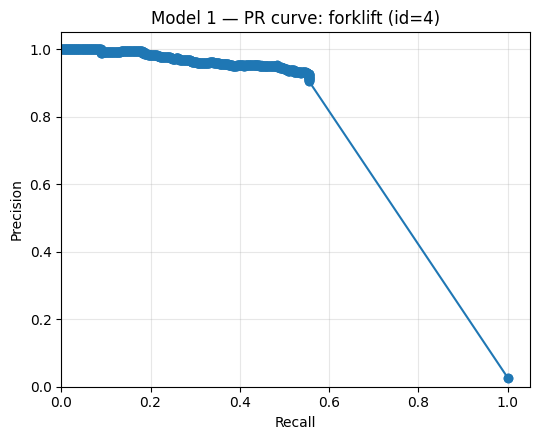

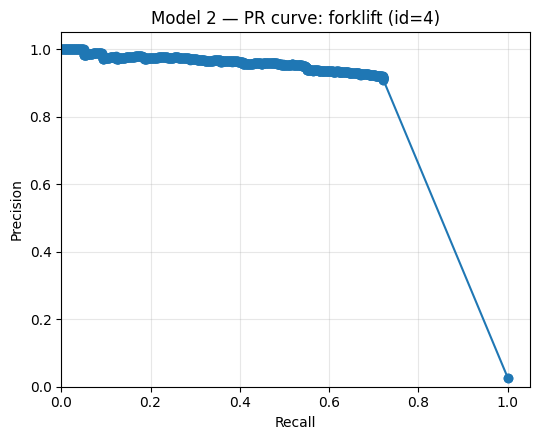

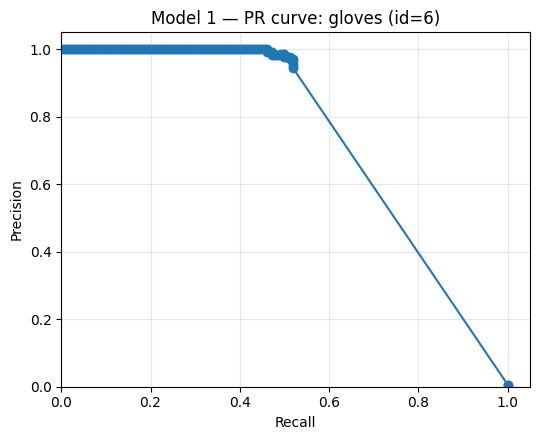

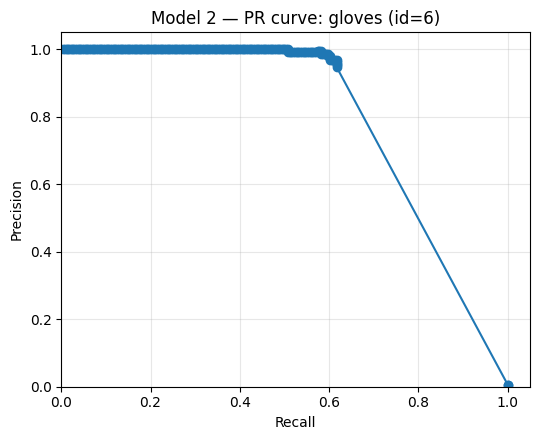

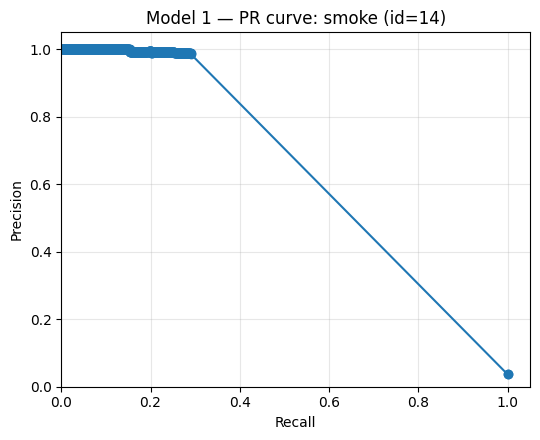

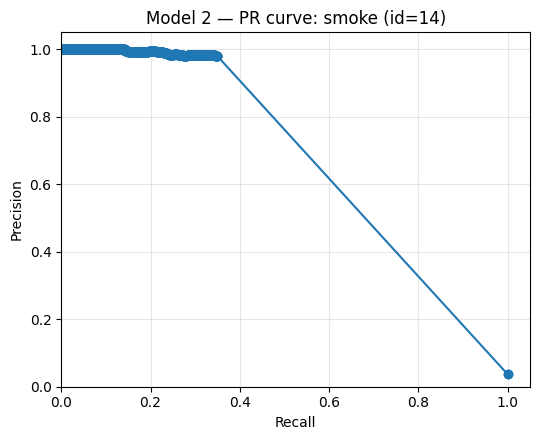

In [13]:

top_diff = df.copy()
top_diff["abs_delta"] = top_diff["delta_AP_(M2-M1)"].abs()
top3 = top_diff.sort_values("abs_delta", ascending=False).head(3)["class_id"].tolist()

for cid in top3:
    plot_pr_for_class(cid, "Model 1", res1["precision"], res1["recall"])
    plot_pr_for_class(cid, "Model 2", res2["precision"], res2["recall"])


## Confusion matrix
We compute a confusion-style matrix based on matched detections only:
- For each ground truth, at most one detection can match it (IoU ≥ threshold), and detections are processed in descending score order.
- The matrix counts `(true_class -> predicted_class)` for matched pairs.

We also compute:
- FP per predicted class: detections that matched no ground truth.
- FN per GT class: GT boxes not matched by any detection.


In [14]:

def iou_xywh(a, b) -> float:
    """
    Compute Intersection over Union (IoU) for two bounding boxes in XYWH format.

    Bounding boxes are represented as [x, y, width, height] where (x, y) is the
    top-left corner. The function calculates the area of overlap divided by the
    area of union.

    Args:
        a (list or tuple of 4 numbers): First bounding box [x, y, w, h].
        b (list or tuple of 4 numbers): Second bounding box [x, y, w, h].

    Returns:
        float: IoU value in range [0.0, 1.0]. Returns 0.0 if union is zero.
    """
    ax, ay, aw, ah = a
    bx, by, bw, bh = b
    ax1, ay1, ax2, ay2 = float(ax), float(ay), float(ax + aw), float(ay + ah)
    bx1, by1, bx2, by2 = float(bx), float(by), float(bx + bw), float(by + bh)

    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0

def confusion_breakdown(result: DatasetResult, iou_thr: float = MAP_IOU_THRESHOLD):
    """
    Compute per-class confusion matrix, false positives, and false negatives.

    Matches ground truth boxes to predicted boxes using greedy assignment based on
    detection score (higher score gets matched first). A match is accepted if the
    IoU is at least `iou_thr`. Unmatched predictions become false positives for the
    predicted class; unmatched ground truths become false negatives for the true class.

    Args:
        result (DatasetResult): Aggregated dataset predictions and ground truths.
        iou_thr (float, optional): IoU threshold to consider a detection as correct.
            Defaults to global MAP_IOU_THRESHOLD.

    Returns:
        tuple: A 3-element tuple containing:
            - conf (np.ndarray): Confusion matrix of shape (NUM_CLASSES, NUM_CLASSES).
                Entry [true_class, pred_class] counts matches.
            - fp (np.ndarray): False positives per class, shape (NUM_CLASSES,).
            - fn (np.ndarray): False negatives per class, shape (NUM_CLASSES,).

    Notes:
        - The function assumes that `result` contains data for all images and that
          bounding boxes are in XYWH format (top-left coordinates).
        - Global constants NUM_CLASSES and MAP_IOU_THRESHOLD are used.
    """
    conf = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
    fp = np.zeros((NUM_CLASSES,), dtype=int)
    fn = np.zeros((NUM_CLASSES,), dtype=int)

    for img_idx in range(len(result.image_files)):
        det_boxes = result.pred_boxes[img_idx]
        det_cls = result.pred_classes[img_idx]
        det_scores = result.pred_scores[img_idx]

        gt_boxes = result.gt_boxes[img_idx]
        gt_cls = result.gt_classes[img_idx]

        # Sort det by score descending
        if len(det_scores) > 0:
            order = np.argsort(np.asarray(det_scores, dtype=float))[::-1]
            det_boxes = [det_boxes[i] for i in order]
            det_cls = [det_cls[i] for i in order]

        matched_gt = set()

        # Greedy matching
        for d in range(len(det_boxes)):
            best_g = -1
            best_iou = 0.0
            for g in range(len(gt_boxes)):
                if g in matched_gt:
                    continue
                iou = iou_xywh(det_boxes[d], gt_boxes[g])
                if iou > best_iou:
                    best_iou = iou
                    best_g = g

            if best_g != -1 and best_iou >= iou_thr:
                matched_gt.add(best_g)
                true_c = int(gt_cls[best_g])
                pred_c = int(det_cls[d])
                if 0 <= true_c < NUM_CLASSES and 0 <= pred_c < NUM_CLASSES:
                    conf[true_c, pred_c] += 1
            else:
                pred_c = int(det_cls[d])
                if 0 <= pred_c < NUM_CLASSES:
                    fp[pred_c] += 1

        # FNs = GTs not matched
        for g in range(len(gt_boxes)):
            if g not in matched_gt:
                true_c = int(gt_cls[g])
                if 0 <= true_c < NUM_CLASSES:
                    fn[true_c] += 1

    return conf, fp, fn

conf1, fp1, fn1 = confusion_breakdown(model1)
conf2, fp2, fn2 = confusion_breakdown(model2)

print("Confusion matrix shapes:", conf1.shape, conf2.shape)
print("Total matched (Model 1):", conf1.sum(), "FP:", fp1.sum(), "FN:", fn1.sum())
print("Total matched (Model 2):", conf2.sum(), "FP:", fp2.sum(), "FN:", fn2.sum())

df = pd.DataFrame([
    {"model": "Model 1", "matched": int(conf1.sum()), "FP": int(fp1.sum()), "FN": int(fn1.sum())},
    {"model": "Model 2", "matched": int(conf2.sum()), "FP": int(fp2.sum()), "FN": int(fn2.sum())},
])
df["total_events"] = df["matched"] + df["FP"] + df["FN"]
display(df)

Confusion matrix shapes: (20, 20) (20, 20)
Total matched (Model 1): 14956 FP: 4346 FN: 21765
Total matched (Model 2): 16845 FP: 3981 FN: 19876


,model,matched,FP,FN,total_events
0,Model 1,14956,4346,21765,41067
1,Model 2,16845,3981,19876,40702


### Confusion matrix visualization (matched pairs only)
This visualizes how often each ground truth class is predicted as each class (diagonal indicates correctness).

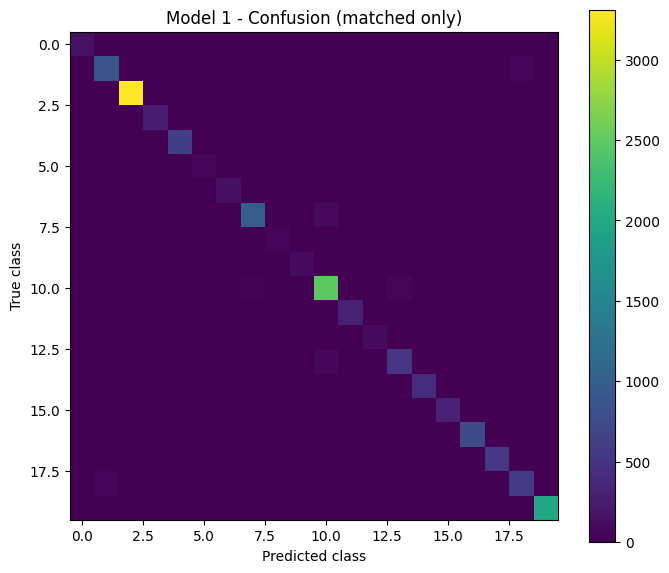

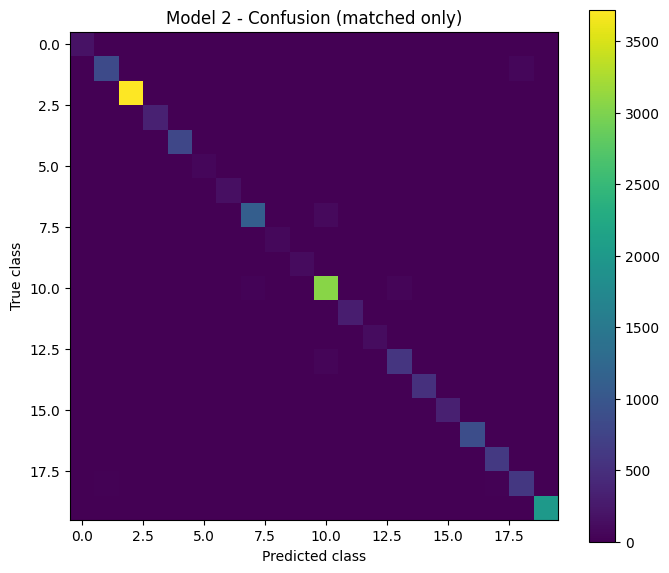

In [20]:

def plot_confusion_matrix(conf: np.ndarray, title: str, max_classes: int = 20):
    n = min(conf.shape[0], max_classes)
    cm = conf[:n, :n]

    plt.figure(figsize=(7, 6))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(conf1, "Model 1 - Confusion (matched only)", max_classes=min(NUM_CLASSES, 20))
plot_confusion_matrix(conf2, "Model 2 - Confusion (matched only)", max_classes=min(NUM_CLASSES, 20))


### Top confusions (true → predicted) excluding correct predictions

Here we print the top-K most frequent off-diagonal entries in the confusion matrix (the most common cases where a true class is predicted as a different class), for Model 1 and Model 2.

In [16]:

def top_confusions(conf: np.ndarray, top_k: int = 10):
    tmp = conf.copy()
    np.fill_diagonal(tmp, 0)
    flat = tmp.flatten()
    idx = np.argsort(flat)[::-1][:top_k]
    rows, cols = np.unravel_index(idx, tmp.shape)
    out = []
    for r, c in zip(rows, cols):
        if tmp[r, c] > 0:
            out.append((CLASS_NAMES[r], CLASS_NAMES[c], int(tmp[r, c])))
    return out

print("Model 1 top confusions:")
for t, p, n in top_confusions(conf1, top_k=10):
    print(f"  {t} -> {p}: {n}")

print("\nModel 2 top confusions:")
for t, p, n in top_confusions(conf2, top_k=10):
    print(f"  {t} -> {p}: {n}")


Model 1 top confusions:
  helmet -> person: 81
  safety vest -> person: 65
  van -> car: 50
  person -> safety vest: 50
  car -> van: 42
  person -> helmet: 34
  truck -> van: 15
  van -> truck: 11
  helmet -> safety vest: 8
  road sign -> traffic light: 7

Model 2 top confusions:
  helmet -> person: 89
  car -> van: 61
  safety vest -> person: 50
  person -> safety vest: 48
  person -> helmet: 34
  van -> truck: 29
  van -> car: 22
  car -> truck: 8
  cardboard box -> qr code: 7
  truck -> van: 7


### FP/FN per class

Below we build a per-class table of false positives and false negatives for both models, compute how those counts change from Model 1 to Model 2 (`M2 − M1`), and then show the classes with the largest increase in FN difference (sorted by `delta_FN`).

In [17]:

fpfn = pd.DataFrame({
    "class_id": list(range(NUM_CLASSES)),
    "class_name": CLASS_NAMES,
    "FP_model1": fp1,
    "FN_model1": fn1,
    "FP_model2": fp2,
    "FN_model2": fn2,
})
fpfn["delta_FP_(M2-M1)"] = fpfn["FP_model2"] - fpfn["FP_model1"]
fpfn["delta_FN_(M2-M1)"] = fpfn["FN_model2"] - fpfn["FN_model1"]

fpfn.sort_values("delta_FN_(M2-M1)", ascending=False).head(20)


,class_id,class_name,FP_model1,FN_model1,FP_model2,FN_model2,delta_FP_(M2-M1),delta_FN_(M2-M1)
5,5,freight container,61,257,36,256,-25,-1
11,11,qr code,49,71,49,66,0,-5
1,1,car,154,484,91,476,-63,-8
18,18,van,26,122,27,111,1,-11
9,9,license plate,8,259,25,246,17,-13
6,6,gloves,4,123,6,98,2,-25
15,15,traffic cone,55,201,49,175,-6,-26
12,12,road sign,41,616,74,590,33,-26
0,0,barcode,28,124,24,96,-4,-28
8,8,ladder,12,220,22,191,10,-29


## Save results

In [18]:

out_ap = os.path.join(CACHE_DIR, "model_comparison_ap_table.csv")
out_fpfn = os.path.join(CACHE_DIR, "model_comparison_fp_fn_table.csv")

df_sorted.to_csv(out_ap, index=False)
fpfn.to_csv(out_fpfn, index=False)

print("Saved:", out_ap)
print("Saved:", out_fpfn)


Saved: C:\Users\Usuario\Downloads\techtrack-hortner87-main(4)\techtrack-hortner87-main\techtrack\storage\cache_model_compare\model_comparison_ap_table.csv
Saved: C:\Users\Usuario\Downloads\techtrack-hortner87-main(4)\techtrack-hortner87-main\techtrack\storage\cache_model_compare\model_comparison_fp_fn_table.csv
